## ASS 2 QUESTION13

In [29]:
from ISLP import load_data
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

## understand the data
### Exploratory data analysis

In [12]:
# loading our dataset
Weekly = load_data('Weekly')
Weekly
#how many columns & rows we have
print(f"Shape: {Weekly.shape}")

#printing 1st five records
print('First 5 Records \n =================')
print(Weekly.head())

Shape: (1089, 9)
First 5 Records 
   Year   Lag1   Lag2   Lag3   Lag4   Lag5    Volume  Today Direction
0  1990  0.816  1.572 -3.936 -0.229 -3.484  0.154976 -0.270      Down
1  1990 -0.270  0.816  1.572 -3.936 -0.229  0.148574 -2.576      Down
2  1990 -2.576 -0.270  0.816  1.572 -3.936  0.159837  3.514        Up
3  1990  3.514 -2.576 -0.270  0.816  1.572  0.161630  0.712        Up
4  1990  0.712  3.514 -2.576 -0.270  0.816  0.153728  1.178        Up


In [ ]:
#checking class balance
print(Weekly['Direction'].value_counts())

Direction
Up      605
Down    484
Name: count, dtype: int64


In [14]:
#numerical summary of our dataset
Weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


In [15]:
Weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1089 non-null   int64   
 1   Lag1       1089 non-null   float64 
 2   Lag2       1089 non-null   float64 
 3   Lag3       1089 non-null   float64 
 4   Lag4       1089 non-null   float64 
 5   Lag5       1089 non-null   float64 
 6   Volume     1089 non-null   float64 
 7   Today      1089 non-null   float64 
 8   Direction  1089 non-null   category
dtypes: category(1), float64(7), int64(1)
memory usage: 69.4 KB


### COrrelayion Matrix
checking correlation between our features

In [ ]:
numeric_cols = ['Year','Lag1','Lag2','Lag3','Lag4','Lag5','Volume','Today']
corr = Weekly[numeric_cols].corr()

         Year   Lag1   Lag2   Lag3   Lag4   Lag5  Volume  Today
Year    1.000 -0.032 -0.033 -0.030 -0.031 -0.031   0.842 -0.032
Lag1   -0.032  1.000 -0.075  0.059 -0.071 -0.008  -0.065 -0.075
Lag2   -0.033 -0.075  1.000 -0.076  0.058 -0.072  -0.086  0.059
Lag3   -0.030  0.059 -0.076  1.000 -0.075  0.061  -0.069 -0.071
Lag4   -0.031 -0.071  0.058 -0.075  1.000 -0.076  -0.061 -0.008
Lag5   -0.031 -0.008 -0.072  0.061 -0.076  1.000  -0.059  0.011
Volume  0.842 -0.065 -0.086 -0.069 -0.061 -0.059   1.000 -0.033
Today  -0.032 -0.075  0.059 -0.071 -0.008  0.011  -0.033  1.000


#### Corr Matrix

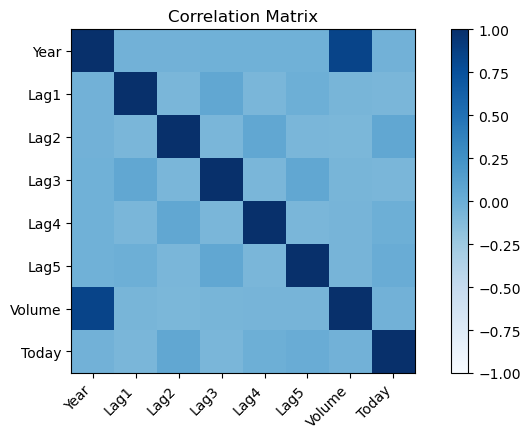

In [28]:
fig0, ax0 = plt.subplots(figsize=(8,4.5))
im = ax0.imshow(corr, cmap="Blues", vmin=-1, vmax=1)

#labels (X & Y axis)
ax0.set_xticks(range(len(numeric_cols)))
ax0.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax0.set_yticks(range(len(numeric_cols)))
ax0.set_yticklabels(numeric_cols)
ax0.set_title('Correlation Matrix')
plt.colorbar(im, ax=ax0, fraction=0.046)
plt.tight_layout()
plt.show()

Lag columns have almost no correlation with each other and today. but volume shows strong correlation with Year

#### Displaying volume over time

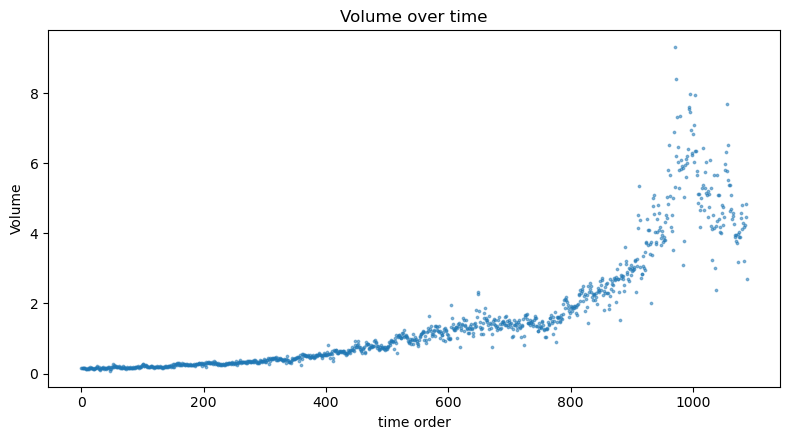

In [26]:
fig, axes = plt.subplots(figsize=(8,4.5))
axes.scatter(range(len(Weekly)), Weekly['Volume'], s=3, alpha=0.5)
axes.set_xlabel('time order')
axes.set_ylabel('Volume')
axes.set_title('Volume over time')
plt.tight_layout()
plt.show()

### Logistic regression
fitting all the data without train & test set to see which predictors, if any, show a statistically significant relationship with Direction.

In [30]:
y = (Weekly['Direction'] == 'Up').astype(int)
X = Weekly[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Mon, 24 Aug 2026   Pseudo R-squ.:                0.006580
Time:                        12:26:29   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

We are interested in only predictors that are statistically significant. meaning columns with P>|z| < 0.05.
#### Confusion matrix and accuracy

In [31]:
probs = result.predict(X)
preds = (probs >= 0.5).astype(int)

cm = confusion_matrix(y, preds)
print(cm)

tn, fp, fn, tp = cm.ravel()
accuracy = (tn + tp) / len(y)
print(f"Overall accuracy: {accuracy:.4f}")
print(f"Down correctly identified: {tn}/{tn+fp} = {tn/(tn+fp):.4f}")
print(f"Up correctly identified: {tp}/{tp+fn} = {tp/(tp+fn):.4f}")

[[ 54 430]
 [ 48 557]]
Overall accuracy: 0.5611
Down correctly identified: 54/484 = 0.1116
Up correctly identified: 557/605 = 0.9207


### Logistic regression on splitted data

**why we need to use statsmodels' constant?**   
Every logistic regression model has an intercept term (usually written β₀):

log-odds = β₀ + β₁·Lag2

β₀ is the baseline — the log-odds of "Up" when Lag2 = 0. Without it, the model is mathematically forced to assume the log-odds is exactly 0 (a 50/50 coin flip) whenever every predictor is 0 — which is basically never true in real data, and forcing it distorts the entire fit, not just the prediction at x=0

In [ ]:
# separating train & test set
# We split by YEAR, because this is time-series data and random split would let the model "peek" at future patterns via nearby rows, which wouldn't reflect how it'd actually be used
train = Weekly[Weekly['Year'] <= 2008] # train set
test = Weekly[Weekly['Year'] > 2008] #test set

y_train = train['Direction'].eq('Up').astype(int)
y_test = test['Direction'].eq('Up').astype(int)

#We use only Lag2 since it's the only predictor that came out significant in part (b)
X_train = sm.add_constant(train[['Lag2']])
X_test = sm.add_constant(test[['Lag2']], has_constant='add')

logit = sm.Logit(y_train, X_train).fit()
probs = logit.predict(X_test)
pred_logit = (probs >= 0.5).astype(int)

cm_logit = confusion_matrix(y_test, pred_logit)
acc_logit = (cm_logit[0,0] + cm_logit[1,1]) / len(y_test)
print(cm_logit)
print(f"Accuracy: {acc_logit:.4f}")

Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
[[ 9 34]
 [ 5 56]]
Accuracy: 0.6250


### LDA

In [ ]:
lda = LinearDiscriminantAnalysis()

#we are not repeating constatant trick because LDA doesn't it.
lda.fit(train[['Lag2']], y_train)
pred_lda = lda.predict(test[['Lag2']])

cm_lda = confusion_matrix(y_test, pred_lda)
acc_lda = (cm_lda[0,0] + cm_lda[1,1]) / len(y_test)
print(cm_lda)
print(f"Accuracy: {acc_lda:.4f}")

[[ 9 34]
 [ 5 56]]
Accuracy: 0.6250


### QDA

In [34]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(train[['Lag2']], y_train)
pred_qda = qda.predict(test[['Lag2']])

cm_qda = confusion_matrix(y_test, pred_qda)
acc_qda = (cm_qda[0,0] + cm_qda[1,1]) / len(y_test)
print(cm_qda)
print(f"Accuracy: {acc_qda:.4f}")
print("Classes predicted:", set(pred_qda))

[[ 0 43]
 [ 0 61]]
Accuracy: 0.5865
Classes predicted: {1}


### KNN, K=1

In [35]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(train[['Lag2']], y_train)
pred_knn = knn1.predict(test[['Lag2']])

cm_knn = confusion_matrix(y_test, pred_knn)
acc_knn = (cm_knn[0,0] + cm_knn[1,1]) / len(y_test)
print(cm_knn)
print(f"Accuracy: {acc_knn:.4f}")

[[21 22]
 [30 31]]
Accuracy: 0.5000


### Naive Bayes

In [36]:
nb = GaussianNB()
nb.fit(train[['Lag2']], y_train)
pred_nb = nb.predict(test[['Lag2']])

cm_nb = confusion_matrix(y_test, pred_nb)
acc_nb = (cm_nb[0,0] + cm_nb[1,1]) / len(y_test)
print(cm_nb)
print(f"Accuracy: {acc_nb:.4f}")
print("Classes predicted:", set(pred_nb))

[[ 0 43]
 [ 0 61]]
Accuracy: 0.5865
Classes predicted: {1}


### Compare all models

In [37]:
results = {
    'Logistic': acc_logit,
    'LDA': acc_lda,
    'QDA': acc_qda,
    'KNN (K=1)': acc_knn,
    'Naive Bayes': acc_nb,
}
for name, acc in sorted(results.items(), key=lambda kv: -kv[1]):
    print(f"{name:15s}: {acc:.4f}")

Logistic       : 0.6250
LDA            : 0.6250
QDA            : 0.5865
Naive Bayes    : 0.5865
KNN (K=1)      : 0.5000


### Experiment

In [38]:
Weekly['Lag1xLag2'] = Weekly['Lag1'] * Weekly['Lag2']   # interaction term
Weekly['Lag2_sq'] = Weekly['Lag2'] ** 2                  # quadratic transform

train = Weekly[Weekly['Year'] <= 2008]
test = Weekly[Weekly['Year'] > 2008]
y_train = train['Direction'].eq('Up').astype(int)
y_test = test['Direction'].eq('Up').astype(int)

experiments = []

def run_logistic(feats, name):
    Xtr = sm.add_constant(train[feats])
    Xte = sm.add_constant(test[feats], has_constant='add')
    m = sm.Logit(y_train, Xtr).fit(disp=0)
    pred = (m.predict(Xte) >= 0.5).astype(int)
    acc = (pred == y_test).mean()
    experiments.append((name, acc))

def run_knn(feats, k, name):
    m = KNeighborsClassifier(n_neighbors=k).fit(train[feats], y_train)
    pred = m.predict(test[feats])
    acc = (pred == y_test).mean()
    experiments.append((name, acc))

# try adding a second predictor and an interaction
run_logistic(['Lag2'], 'Logistic: Lag2 only (baseline)')
run_logistic(['Lag1','Lag2'], 'Logistic: Lag1+Lag2')
run_logistic(['Lag1','Lag2','Lag1xLag2'], 'Logistic: Lag1+Lag2+interaction')
run_logistic(['Lag2','Lag2_sq'], 'Logistic: Lag2+Lag2^2')

# sweep K for KNN, since K=1 (part g) is known to be high-variance/noisy
for k in [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]:
    run_knn(['Lag2'], k, f'KNN (K={k}): Lag2 only')

experiments.sort(key=lambda x: -x[1])
for name, acc in experiments:
    print(f"{name:35s}{acc:.4f}")

Logistic: Lag2 only (baseline)     0.6250
Logistic: Lag2+Lag2^2              0.6250
KNN (K=15): Lag2 only              0.5865
Logistic: Lag1+Lag2                0.5769
Logistic: Lag1+Lag2+interaction    0.5769
KNN (K=51): Lag2 only              0.5673
KNN (K=3): Lag2 only               0.5577
KNN (K=11): Lag2 only              0.5577
KNN (K=21): Lag2 only              0.5577
KNN (K=7): Lag2 only               0.5481
KNN (K=9): Lag2 only               0.5481
KNN (K=31): Lag2 only              0.5385
KNN (K=5): Lag2 only               0.5288
KNN (K=1): Lag2 only               0.5000
